# From Linear Models to Neural Networks
Linear models occupy a special place in machine learning because they are mathematically simple, computationally efficient, and geometrically interpretable. Linear models often provide a clear definition of what constitutes an optimal model. In regression, we could easily determine the globally optimal model. In the SVM, linearity helps to define and compute the most robust hyperplane that maximizes the margin. Importantly, linear models are not necessarily restricted to learning linear relationships in the original input space. We can transform the data to higher dimensional feature spaces where nonlinear relationships appear linear. This we have seen with the basis functions in regression and the kernel trick for the SVM.

However, transforming into higher dimensional feature spaces via a kernel or basis functions scales poorly with large datasets and require an ad hoc selection of the feauture transformation. Neural networks address this issue by learning a feature transformation that fits to the data and task at hand. At their core, neural networks are function approximators composed of simple layers of interconnected nodes. Although neural networks have been originally proposed in the 1950s with the perceptron, the breakthrough came in the 2010s, fueled by larger datasets, faster GPUs, and architectural innovations.

Although neural networks can be used in a versatile way to learn any kind of function, one of their most successful use cases is in classification. Neural network classifiers train a linear classifier together with the feature transformation, which makes them exceptionally powerful in high-dimensional, unstructured domains like images, audio, and text. The linear classifier they typically use is the logistic regression, which we introduce now.

## Logistic Regression

Logistic regression is a binary classification model, that finds a hyperplane separating the classes like the SVM. In contrast to the SVM, the goal of logistic regression is not to find the maximum margin hyperplane, but to predict the class with highest posterior probability
$$\hat{y}(\vvec{x}) = \argmax_{1\leq y\leq c} p(y\mid \mathbf{x}).$$
Logistic regression uses the distance of a point to the separating hyperplane to model the posterior probability such that pushing a point away from the separating hyperplane increases the posterior probability of the corresponding class. The idea is that uncertainty in the classification is high when we are near the decision boundary - reflected by a low posterior probability of the predicted class. The further we are away from the decision boundary, the more confident we become in our prediction and the posterior probability increases. This way, the posterior probabilities can be interpreted as a confidence measure. The plot below indicates a separating hyperplane and the confidence assigned by logistic regression. We see that the confidence is low near the decision boundary and increases rapidly away from it.

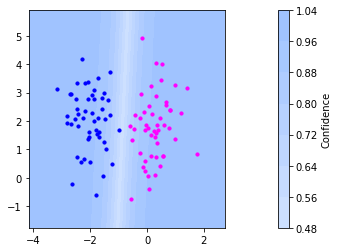

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
cm_0 = LinearSegmentedColormap.from_list("mycmap", ["#ffffff","#a0c3ff"])
def plot_conf(classifier_prob, show_class_assignment=False, x_max=20, y_max=20, x_min=-1, y_min=-1):
    d,c = 2, len(clf.classes_)
    #plt.set_cmap(cm_0)
    x_ = np.arange(x_min, x_max, 0.05)
    y_ = np.arange(y_min, y_max, 0.05)

    xx, yy = np.meshgrid(x_, y_)
    XY = np.array([xx,yy]).reshape(2,x_.shape[0]*y_.shape[0]).T
    Z = classifier_prob(XY).T
    Z = Z.reshape(c,y_.shape[0],x_.shape[0])

    h = plt.contourf(x_,y_,Z.max(axis=0), cmap=cm_0)
    plt.clim(0, 1)   
    cb = plt.colorbar()
    cb.set_label('Confidence')
    plt.axis('scaled')
     
X, y = make_blobs(n_samples=100, centers=[[-5, 0], [0, 1.5]], random_state=40)
transformation = np.array([[0.4, 0.2], [-0.4, 1.2]]).T
X = np.dot(X, transformation)

clf = LogisticRegression(
    solver="sag", max_iter=100, random_state=42).fit(X, y)

plot_conf(clf.predict_proba,show_class_assignment=False, x_max =max(X[:,0])+1, y_max =max(X[:,1])+1, x_min =min(X[:,0])-1, y_min =min(X[:,1])-1)
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', s=10)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='magenta', s=10)
plt.show()

Recall from what we discussed regarding the SVM that $\lvert\mathbf{w}^\top \mathbf{x} + b\rvert = dist(\mathbf{x},\mathcal{H}_{\vvec{w},b})\lVert\vvec{w}\rVert$ is the scaled distance of point $\vvec{x}$ to the hyperplane defined by $\vvec{w}$ and $b$. Logistic regression turns the linear score $\mathbf{w}^\top \mathbf{x} + b$ into a quantity that can be interpreted as probability of assigning the point $\mathbf{x}$ to either class. Logistic regression achieves this by applying the sigmoid function 
$$\sigma(x) = \frac{1}{1 + \exp^{-x}}$$
to the linear score. 

The sigmoid maps large positive values close to $1$, large negative values close to $0$, and values near the decision boundary close to $0.5$. In addition, it is a smooth function that can be optimized with gradient descent. The plot below shows the sigmoid function.

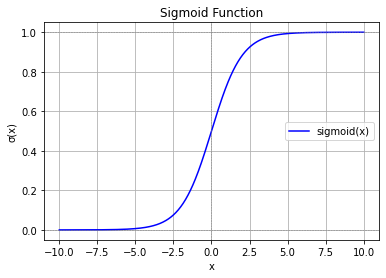

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define the sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Create input values
x = np.linspace(-10, 10, 500)
y = sigmoid(x)

# Plot
plt.plot(x, y, label='sigmoid(x)', color='blue')
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.axhline(1, color='gray', linewidth=0.5, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.grid(True)
plt.legend()
plt.show()


The resulting predicted probability with which a point $\mathbf{x}$ is assigned to class 1, is then computed as
$$
P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b).
$$

## Softmax Regression
For multiclass classification, the softmax regression generalizes logistic regression to $c$ classes by learning one hyperplane per class. The confidence of a class increases the more we go in direction of the normal vector $\vvec{w}_l$. The confidence is again interpreted as probability that a sample belongs to a class, which is now computed over the softmax function. The plot below shows how softmax regression models decision boundaries based on three hyperplanes. Both plots indicate the confidence as a heatmap. You can see the decision boundaries are the white lines. On the left you see a plot of each hyperplane $\vvec{w}_l^\top \vvec{x}+b_l=0$ as the thick solid lines together with the corresponding normal vector, indicated by the arrows. The dashed lines indicate the level sets where $\vvec{w}_l^\top \vvec{x}+b_l\in\{2,4,6\}$. On the right you see the confidence plot together with the training data.

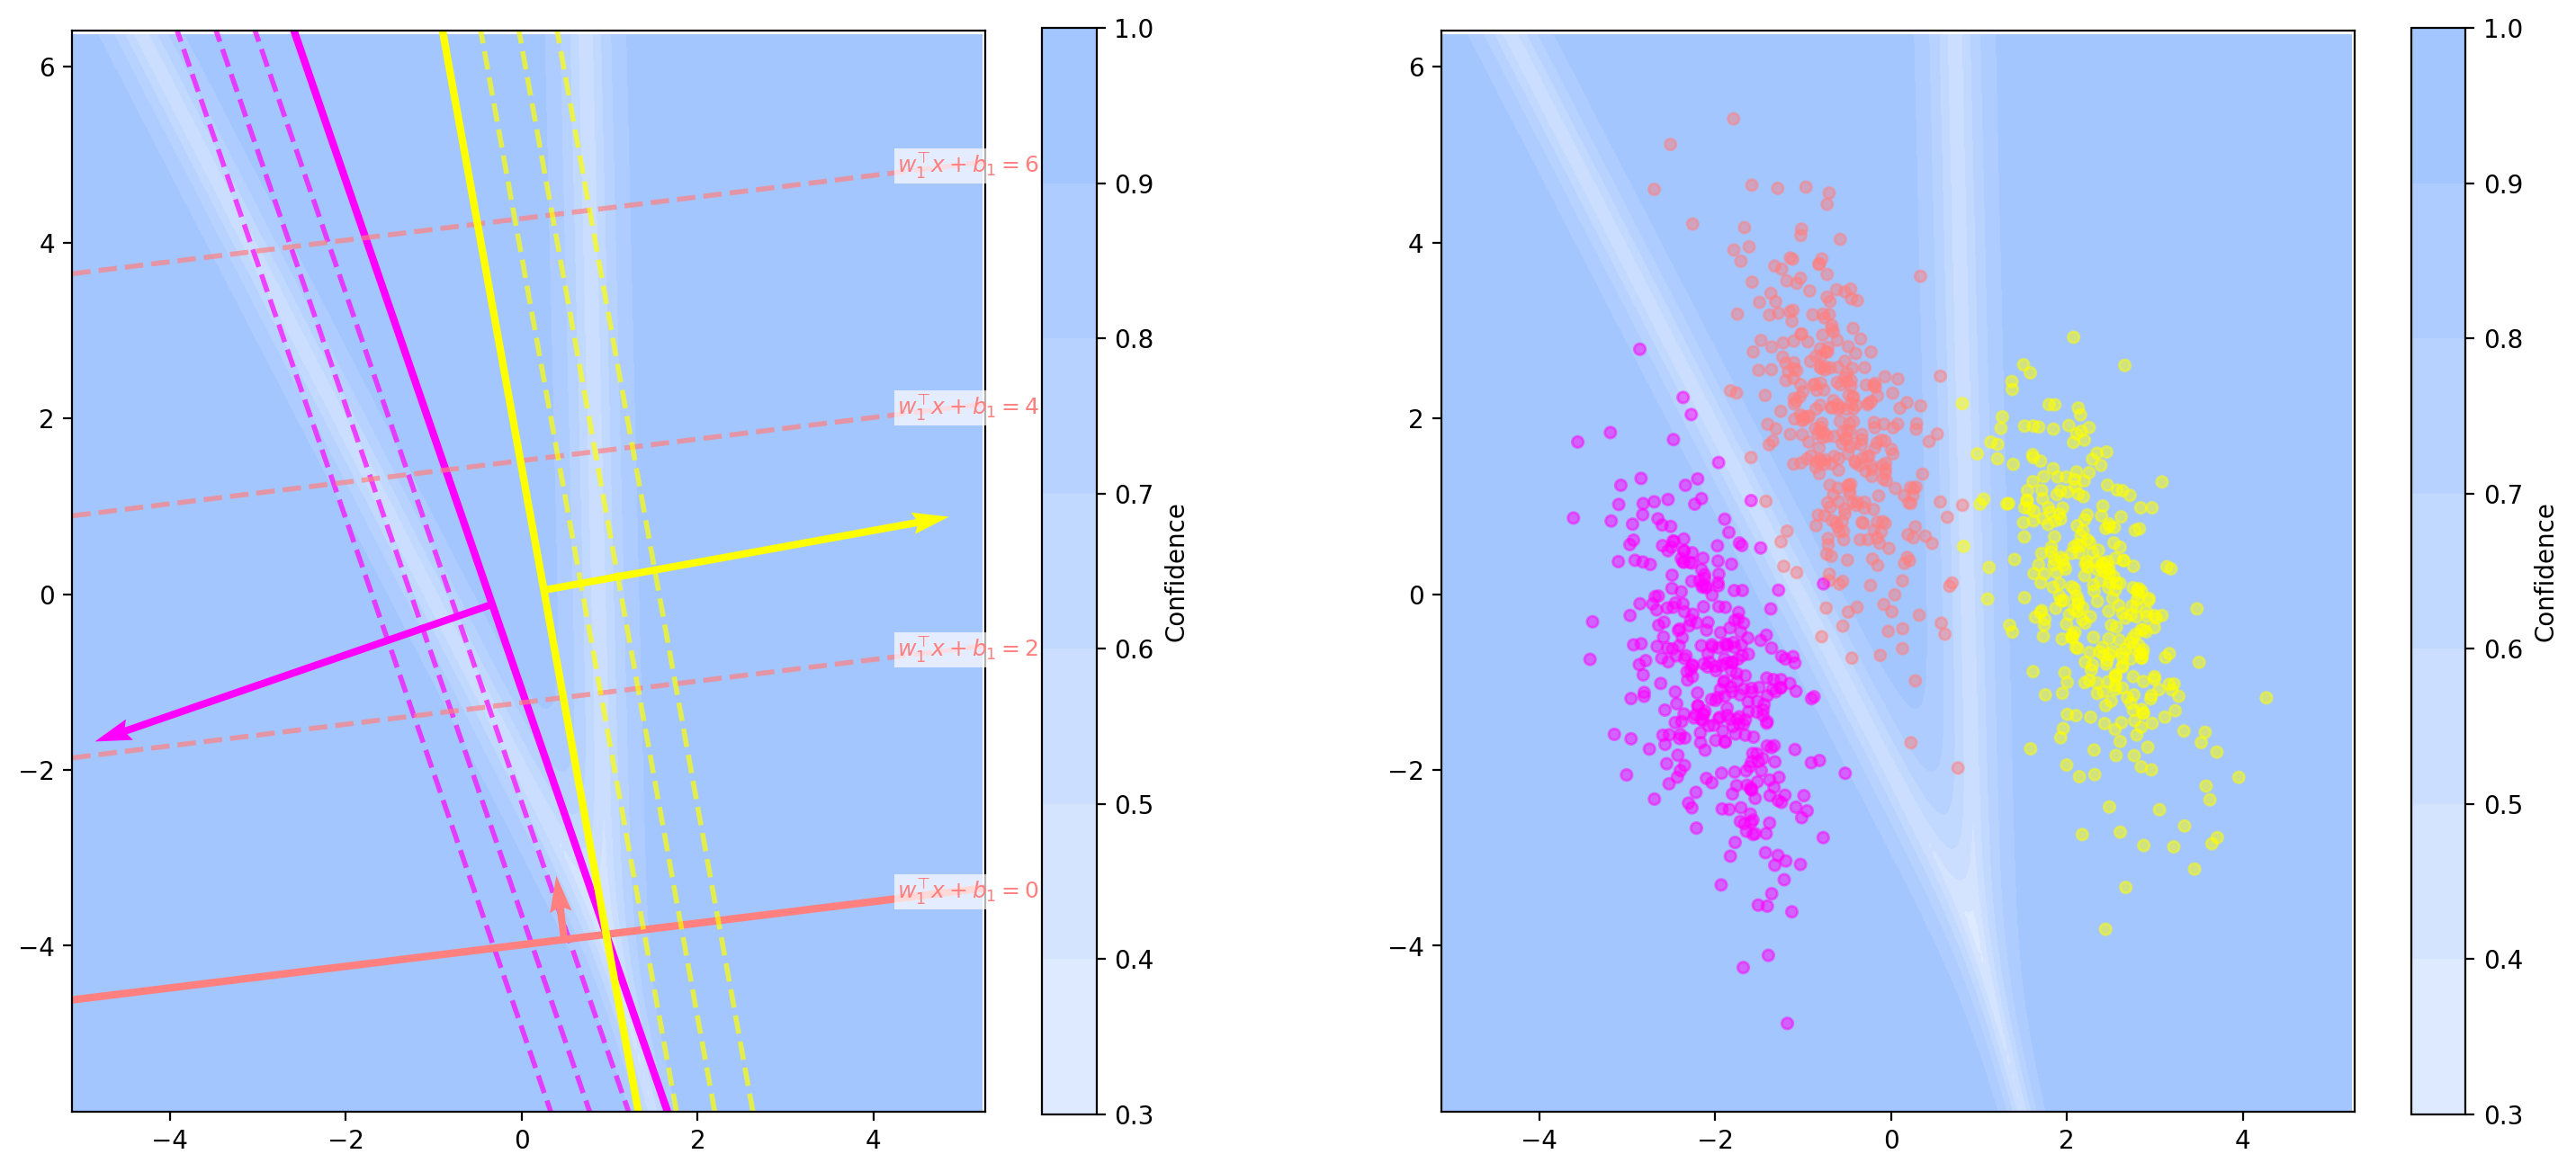

In [63]:
# make 3-class dataset for classification
#plt.figure(figsize=(8, 3),dpi=200)
fig, axes = plt.subplots(1, 2, figsize=(18, 8),dpi=200)
ax1, ax2 = axes

centers = [[-5, 0], [0, 1.5], [5, -1]]
X, y = make_blobs(n_samples=1000, centers=centers, random_state=40)

transformation = [[0.4, 0.2], [-0.4, 1.2]]
X = np.dot(X, transformation)

multi_class = "multinomial"

clf = LogisticRegression(
    solver="sag",
    max_iter=100,
    random_state=42,
    multi_class=multi_class
).fit(X, y)

coef = clf.coef_
intercept = clf.intercept_
xmin, xmax = min(X[:, 0]) - 1.5, max(X[:, 0]) + 1
ymin, ymax = min(X[:, 1]) - 1, max(X[:, 1]) + 1

for ax in [ax1, ax2]:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")

def plot_conf(ax, classifier_prob, show_class_assignment=False, x_max=20, y_max=20, x_min=-1, y_min=-1):
    d,c = 2, len(clf.classes_)
    #plt.set_cmap(cm_0)
    x_ = np.arange(x_min, x_max, 0.05)
    y_ = np.arange(y_min, y_max, 0.05)

    xx, yy = np.meshgrid(x_, y_)
    XY = np.array([xx,yy]).reshape(2,x_.shape[0]*y_.shape[0]).T
    Z = classifier_prob(XY).T
    Z = Z.reshape(c,y_.shape[0],x_.shape[0])

    h = ax.contourf(x_,y_,Z.max(axis=0), cmap=cm_0)
    
    h.set_clim(0, 1)   
    cb = plt.colorbar(h,ax=ax)
    cb.set_label('Confidence')

# plot confidence background
plot_conf(
    ax2,
    clf.predict_proba,
    show_class_assignment=False,
    x_max=xmax,
    y_max=ymax,
    x_min=xmin,
    y_min=ymin,
)

# plot confidence background
plot_conf(
    ax1,
    clf.predict_proba,
    show_class_assignment=True,
    x_max=xmax,
    y_max=ymax,
    x_min=xmin,
    y_min=ymin,
)

# scatter plot
sc = ax2.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    s=20,
    alpha=0.5,
    cmap="spring"
)


def plot_hyperplanes(ax, c, color, levels=[0, 2, 4, 6]):
    w = coef[c]
    b = intercept[c]

    for level in levels:

        def line(x0):
            return (-w[0] * x0 - b + level) / w[1]

        # style for decision boundary
        if level == 0:
            linestyle = "-"
            linewidth = 3
            alpha = 1.0
        else:
            linestyle = "--"
            linewidth = 2
            alpha = 0.7

        # draw line
        ax.plot(
            [xmin, xmax],
            [line(xmin), line(xmax)],
            color=color,
            linestyle=linestyle,
            linewidth=linewidth,
            alpha=alpha,
        )

        # label position
        x_text = xmax - 1
        y_text = line(x_text)

        # avoid labels outside plot
        if ymin < y_text < ymax:
            ax.text(
                x_text,
                y_text,
                rf"$w_{c}^\top x + b_{c} = {level}$",
                color=color,
                fontsize=9,
                bbox=dict(
                    facecolor="white",
                    alpha=0.7,
                    edgecolor="none",
                    pad=1
                )
            )

def plot_weight_vector(ax, c, color, scale=1):
    w = coef[c]
    b=intercept[c]

    # normalize for visualization
    w_norm = w / np.linalg.norm(w)
    
    # point on hyperplane closest to origin
    base = -b * w / np.dot(w, w)

    ax.quiver(
        base[0], base[1],                 # start at origin
        w[0], w[1],           # vector components
        angles="xy",
        scale_units="xy",
        scale=1 ,
        color=color,
        width=0.008,
        zorder=10
    )
# plot all classes
for k in clf.classes_:
    plot_weight_vector(ax1, k, sc.to_rgba(k))
    plot_hyperplanes(ax1, k, sc.to_rgba(k))

plt.show()

We observe that the level sets for the orange class are more widely spaced than for the other classes. This is due to the smaller norm of the orange normal vector. Since
\begin{align*}
&\mathbf{w}^\top \mathbf{x} + b = z & 
\Leftrightarrow \quad  dist(\mathbf{x},\mathcal{H}_{\vvec{w},b})\lVert\vvec{w}\rVert = z
\end{align*}
smaller values of $\lVert\vvec{w}\rVert$ imply that the point $\vvec{x}$ must lie farther away from the orange hyperplane than from the yellow or purple hyperplanes in order to reach the same level set $z$.

Softmax regression models uncertainty over the level sets quantities
$$z_l = \vvec{w}_l^\top \vvec{x}+b_l$$
that are also called **logits**. We predict the class with the maximum logit and become uncertain about our prediction when the maximum logits have similar values. This way, the decision boundaries are generated as the points where at least two hyperplanes achieve the maximum logit value.
For example, in the plot above we can see how the decision boundary between the yellow and orange class contains those points where the first, second, and respectively third level sets for orange and yellow meet.

Softmax Regression uses the softmax function to transform the logits into posterior probabilities
$$\mathrm{softmax}:\mathbb{R}^d\rightarrow [0,1]^c, \ \mathrm{softmax}(\vvec{z})_y=\frac{\exp(z_y)}{\sum_{j=1}^c\exp(z_j)}.$$ 
Softmax gets its name from being a smooth version of the $\argmax$ function. While $\argmax$ selects only the class with the highest logit, softmax converts all logits into probabilities, assigning exponentially larger probabilities to larger logits.
```{prf:example}
We compute the softmax confidence for point $\vvec{x}=(0,2)$ and the hyperplanes from the plot above
\begin{align*}
z_{1} &= -0.1 x_1 +0.7 x_2 +2.9 = 4.3 & \text{(orange)}\\
z_{2} &= -4.5 x_1 -1.5 x_2 -1.7 = -4.7& \text{(purple)}\\
z_{3} &= 4.6 x_1 + 0.8 x_2 -1.2 = 0.4 & \text{(yellow)}
\end{align*}
We observe how the logits indicate whether the point is on the positive or negative side of the class hyperplane. The point $(0,2)$ is further away from the orange hyperplane in direction of the normal vector. Correspondingly, the logit for the orange class is high. The point is on the negative side of the purple hyperplane, resulting in a negative logit. And it is close to the yellow hyperplane, but on the positive side, indicated by a small, positive logit. Softmax converts these scores now into a probability vector:
\begin{align*}
softmax(\vvec{z})_{1} &= \frac{\exp( 4.3)}{\exp( 4.3) + \exp( -4.7) + \exp( 0.4)} \approx 0.98 \\
softmax(\vvec{z})_{2} &= \frac{\exp( -4.7)}{\exp( 4.3) + \exp( -4.7) + \exp( 0.4)} \approx 0.0001\\
softmax(\vvec{z})_{3} &= \frac{\exp( 0.4)}{\exp( 4.3) + \exp( -4.7) + \exp( 0.4)} \approx 0.02
\end{align*}
As a result, we have 
$$
softmax(\vvec{z}) \approx \begin{pmatrix}0.98\\ 0.0001\\ 0.02\end{pmatrix}.
$$
That is, the confidence for the point being assigned to the first (orange) class is very high. Larger logits receive exponentially larger probabilities due to the definition of softmax as the proportional exponential term.
```

We have now all the ingredients to define the inference of Softmax Regression.

AttributeError: module 'matplotlib.pyplot' has no attribute 'get_figure'

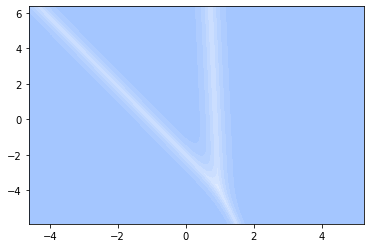

In [40]:
# make 3-class dataset for classification
centers = [[-5, 0], [0, 1.5], [5, -1]]
X, y = make_blobs(n_samples=1000, centers=centers, random_state=40)
transformation = [[0.4, 0.2], [-0.4, 1.2]]
X = np.dot(X, transformation)

multi_class  = "multinomial"
clf = LogisticRegression(
    solver="sag", max_iter=100, random_state=42, multi_class=multi_class
).fit(X, y)


coef = clf.coef_
intercept = clf.intercept_
plot_conf(plt, clf.predict_proba, show_class_assignment=False, x_max =max(X[:,0])+1, y_max =max(X[:,1])+1, x_min =min(X[:,0])-1, y_min =min(X[:,1])-1)
sc = plt.scatter(X[:, 0], X[:, 1], c=y, s=20, alpha=0.5, cmap="spring")
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
def plot_hyperplane(c, color):
    def line(x0):
        return (-(x0 * coef[c, 0]) - intercept[c]) / coef[c, 1]

    plt.plot([xmin, xmax], [line(xmin), line(xmax)],  color=color)

#cmap = plt.cm.get_cmap("gist_rainbow")

for k in clf.classes_:
    plot_hyperplane(k, sc.to_rgba(k))
plt.show()

```{prf:definition} Softmax Regression
The **softmax regression** (a.k.a. multinomial logistic regression) classifier computes the probability that point $\vvec{x}$ belongs to class $y$ by means of $c$ hyperplanes, defined by parameters $\vvec{w}_l$ and $b_l$. Gathering the $c$ hyperplane defining parameters in a matrix $W$, such that $W_{l\cdot} = \vvec{w}_l^\top$, and $\vvec{b}$, then the softmax regression classifier models the probability that point $\vvec{x}$ belongs to class $l$ over the parameters $W$ and $\vvec{b}$
\begin{align*}
f_{sr}(\vvec{x})_l&=p(y = l \mid \mathbf{x},W,\vvec{b})\\ 
&=\mathrm{softmax}(W\vvec{x}+\vvec{b})_l\\
&= \frac{\exp(\vvec{w}_l^\top \mathbf{x} + b_l)}{\sum_{j=1}^{c} \exp(\mathbf{w}_j^\top \mathbf{x} + b_j)}
\end{align*}

```



## Training
The goal of logistic and softmax regression is to maximize the posterior probabilties. Let $\theta=(W,\vvec{b})$ be the parameters of the model. With respect to the training data $\mathcal{D}=\{(\vvec{x}_i,y_i)\mid 1\leq i\leq n, y_i\in\{1,\ldots,c\}\}$, we want to maximize the probability to observe the labels for the provided observations
$$\max_\theta p(y_1,\ldots,y_n\mid \vvec{x}_1,\ldots,\vvec{x}_n,\theta).$$
If we assume that the observations in the training dataset are sampled i.i.d., then this probability factorizes into 
$$\max_\theta p(y_1\mid\vvec{x}_1,\theta)\cdot \ldots \cdot p(y_n\mid\vvec{x}_n,\theta) =\max_\theta \prod_{i=1}^n p(y_i\mid \vvec{x}_i,\theta).$$
As discussed in the scope of naive Bayes, computing the product of probabilities is generally not a good idea, because we might run into underflow. Hence, we apply again the log-probabilities trick and minimize the log-probabilities instead of the probabilities directly. We divide by the number of samples in the dataset and apply the logarithm to Eq. {eq}`eq:obj_smr` and obtain the equivalent objective
\begin{align*}
\max_{\theta} \frac1n \log\prod_{i=1}^n p(y=y_i\mid \vvec{x}_i,\theta) =
\max_{\theta} \frac1n \sum_{i=1}^n\log p(y=y_i\mid \vvec{x}_i,\theta)
\end{align*}
Instead of maximizing the logarithmic values, which are negative, we further multiply with minus one and obtain the following equivalent objective, introducing the cross entropy:
\begin{align*}
\min_{\theta} -\frac1n \sum_{i=1}^n\log p(y_i\mid \vvec{x}_i,\theta)=
\min_{\theta} \frac1n \sum_{i=1}^nCE(y_i,p(y_i\mid \vvec{x}_i,\theta)).
\end{align*}
```{prf:definition} Cross-entropy
The cross entropy is a function $CE:\{1,\ldots,c\}\times [0,1]^c\rightarrow \mathbb{R}_+$,
mapping a label $y\in\{1,\ldots,c\}$ and a probability vector $\vvec{p}\in[0,1]^c$ to the negative logarithm of the probability vector at position $y$:
$$CE(y,\vvec{p}) = -\log(p_y).$$
```
Cross entropy is a popular loss for classification tasks, since it penalizes heavily low probability predictions for the correct class. This is particularly useful in numerical optimization to converge to a reasonable solution quickly, even if the initialization isn't great. We summarize now the task of softmax regression as depicted below.
`````{admonition} Task (softmax regression)
:class: tip
:name: softmax_regr_task
**Given** a classification training data set that is sampled i.i.d. $\mathcal{D}=\{(\vvec{x}_i,y_i)\mid 1\leq i\leq n, y_i\in\{1,\ldots,c\}\}$.       

**Find** the parameters $\theta=(W,\vvec{b})$ such that the posterior probabilities, that are modeled as
$$p(y=l\mid \vvec{x},\theta) = \softmax(W\vvec{x}+\vvec{b})_l$$
are maximized
:::{math}
:label: eq:obj_smr
\begin{align*}\min_{\theta}\mathcal{L}(\theta,\mathcal{D}) = \min_\theta \frac{1}{n} \sum_{i=1}^n CE(y_i,p(y_i\mid \vvec{x}_i,\theta))
\end{align*}
:::
**Return** the classifier defining parameters $\theta$.
`````
## Softmax Regression as a Computational Graph
Softmax regression can already be viewed as a very small neural network consisting of an input layer and an output layer without hidden units.
The plot below shows a visualization of the softmax regression model as it is common for neural networks. The affine function is visualized by the edges connecting the input layer on the left with the output layer. The output layer has $c$ nodes, one for each class. Every edge has a weight that is given by the matrix $W$. For example, the edge from input node $x_i$ to output class node $l$ is $W_{il}$. At each output node, the weighted sum of the edge weights multiplied with the input is computed, the bias term is added and the softmax function is applied.
```{tikz}
\tikzset{%
  every neuron/.style={
    circle,
    draw,
    minimum size=0.5cm
  },
  neuron missing/.style={
    draw=none, 
    scale=2,
    text height=0.25cm,
    execute at begin node=$\vdots$
  },
}

\begin{tikzpicture}[x=1.5cm, y=1cm, >=stealth]

\foreach \m/\l [count=\y] in {1,2,3,missing,4}
  \node [every neuron/.try, neuron \m/.try] (input-\m) at (0,2.5-\y) {};

\foreach \m [count=\y] in {1,missing,2}
  \node [every neuron/.try, neuron \m/.try ] (output-\m) at (1.5,1.5-\y) {};

\foreach \l [count=\i] in {1,2,3,d}
  \draw [<-] (input-\i) -- ++(-0.7,0)
    node [above, midway] {$x_\l$};

\foreach \l [count=\i] in {1,c}
  \draw [->] (output-\i) -- ++(2.8,0)
    node [above, midway] {$\mathrm{softmax}(W\mathbf{x}+\mathbf{b})_\l$};

\foreach \i in {1,...,4}
  \foreach \j in {1,...,2}
    \draw [->] (input-\i) -- (output-\j);


\node [above right=-0.1cm and 0.8cm of input-1.north] {$W$};
\end{tikzpicture}
```
The output of the final layer before the application of the softmax function are also called the **logits**. For the simple softmax regression problem, the logits are hence given by the vector $\vvec{z} = W\vvec{x}+\vvec{b}$. 

## Representation Learning

Logistic or Softmax regression rely on linear decision boundaries. In practice, data often lies on complex, nonlinear manifolds. Hence, we apply a similar trick as we have seen in linear regression and the SVM to use a linear model for nonlinear problems by applying a feature transformation first. In regression, the feature transformation is given by the basis functions and in the SVM it is implicitly defined over the kernel. Neural networks **learn the feature transformation** by stacking various simple functions after one another, whose parameters are optimized jointly with the classifier's parameters. That is we get something that looks like that:

```{tikz}
\tikzset{%
  every neuron/.style={
    circle,
    draw,
    minimum size=0.5cm
  },
  neuron missing/.style={
    draw=none, 
    scale=2,
    text height=0.25cm,
    execute at begin node=$\vdots$
  },
}

\begin{tikzpicture}[x=1.5cm, y=1cm, >=stealth]

\foreach \m/\l [count=\y] in {1,2,3,missing,4}
  \node [every neuron/.try, neuron \m/.try] (input-\m) at (0,2.5-\y) {};

\foreach \m [count=\y] in {1,missing,2}
  \node [every neuron/.try, neuron \m/.try ] (hidden1-\m) at (1.3,2.4-\y*1.5) {};

\foreach \m [count=\y] in {1,missing,2}
  \node [every neuron/.try, neuron \m/.try ] (hidden2-\m) at (3,2.4-\y*1.5) {};

\foreach \m [count=\y] in {1,missing,2}
  \node [every neuron/.try, neuron \m/.try ] (output-\m) at (4.5,1.5-\y) {};

\foreach \l [count=\i] in {1,2,3,d}
  \draw [<-] (input-\i) -- ++(-0.7,0)
    node [above, midway] {$x_\l$};

\foreach \l [count=\i] in {1,d_L}
  \node [above] at (hidden2-\i.north) {$\phi(x)_{\l}$};

\foreach \l [count=\i] in {1,c}
  \draw [->] (output-\i) -- ++(3,0)
    node [above, midway] {$\mathrm{softmax}(W\phi(\mathbf{x})+\mathbf{b})_\l$};

\foreach \i in {1,...,4}
  \foreach \j in {1,...,2}
    \draw [->] (input-\i) -- (hidden1-\j);

\foreach \i in {1,...,2}
  \foreach \j in {1,...,2}
    \draw [->] (hidden1-\i) -- (hidden2-\j);

    \draw [->] (hidden2-1) -- (output-1);
    \draw [->] (hidden2-2) -- (output-1);
    \draw [->] (hidden2-1) -- (output-2);
    \draw [->] (hidden2-2) -- (output-2);
\node [above right=-0.1cm and 0.8cm of hidden2-1.north] {$W$};

\node[scale=2,inner xsep=0pt,inner ysep=5mm] at ($(hidden1-1)!.5!(hidden2-2)$) {$\dots$};

    

\end{tikzpicture}
```

On the left we see the vector $\vvec{x}$ being put as input to the graph, producing an intermediate output $\phi(\vvec{x})$, that is the feature transformation that is classified with a softmax regression, creating the output of the graph. We discuss in the following how we can interpret this graph and how the feature transformation $\phi$ is computed. 